# Comparación de Arquitecturas: LSTM vs GRU vs CNN-LSTM vs Transformer
## Predicción de retornos logarítmicos de BTC-USD

**Objetivo:** Evaluar si cambiar la arquitectura de la red neuronal mejora la capacidad
predictiva sobre los retornos logarítmicos de Bitcoin.

**Metodología:** Se mantiene **todo constante** (datos, split 80/10/10, StandardScaler,
LOOK_BACK=60, callbacks) y solo se varía la arquitectura. De esta forma, cualquier
diferencia en el rendimiento se debe exclusivamente al diseño de la red.

**Arquitecturas a comparar:**

| # | Arquitectura | Idea central |
|---|---|---|
| 1 | **LSTM** (baseline neural) | Memoria de largo plazo con compuertas de olvido |
| 2 | **GRU** | Variante simplificada de LSTM (menos parámetros, misma idea) |
| 3 | **CNN-LSTM** | Conv1D extrae patrones locales, LSTM modela la secuencia |
| 4 | **Transformer** | Atención multi-cabeza, sin recurrencia |

Todas se comparan contra el **baseline naive** (mañana = hoy).

---
### 1 — Librerías y reproducibilidad

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Input,
    Conv1D, MaxPooling1D, Flatten,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibilidad
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
GPU disponible: False


---
### 2 — Carga de datos y preparación

Reutilizamos el mismo pipeline del notebook principal: descarga de BTC-USD,
cálculo de retornos logarítmicos, split temporal 80/10/10, y StandardScaler.

In [3]:
# -----------------------------------------
# Data acquisition (idéntico al notebook principal)
# -----------------------------------------
DATA_CSV_CANDIDATES = [
    Path("data/BTC-USD.csv"),
    Path("../data/BTC-USD.csv"),
    Path("../../data/BTC-USD.csv"),
    Path("BTC-USD.csv"),
]

def try_load_cached_csv():
    for p in DATA_CSV_CANDIDATES:
        if p.exists():
            df = pd.read_csv(p, parse_dates=["Date"]).set_index("Date").sort_index()
            print(f"✅ Loaded cached BTC data from: {p.resolve()}")
            return df
    return None

df_btc = None
try:
    import yfinance as yf
    df_btc = yf.download("BTC-USD", start="2015-01-01", interval="1d", auto_adjust=False, progress=False)
    if df_btc is None or len(df_btc) == 0:
        raise RuntimeError("Empty download")
    df_btc = df_btc.reset_index().set_index("Date").sort_index()
    print(f"✅ Downloaded BTC-USD. Rows: {len(df_btc)}")
    out_cache = Path("data/BTC-USD.csv")
    try:
        out_cache.parent.mkdir(parents=True, exist_ok=True)
        df_btc.reset_index().to_csv(out_cache, index=False)
    except: pass
except Exception as e:
    print(f"⚠️ yfinance failed: {e}")
    df_btc = try_load_cached_csv()

if df_btc is None:
    raise FileNotFoundError("No BTC data available.")

if isinstance(df_btc.columns, pd.MultiIndex):
    df_btc.columns = df_btc.columns.get_level_values(0)

close = df_btc[["Close"]].dropna().astype(float)

# Retorno logarítmico + eliminar NaN
close['Log_Return'] = np.log(close['Close'] / close['Close'].shift(1))
close = close.dropna()

print(f"Rango: {close.index.min().date()} → {close.index.max().date()} | Filas: {len(close)}")

✅ Downloaded BTC-USD. Rows: 4119
Rango: 2015-01-02 → 2026-04-11 | Filas: 4118


In [4]:
# -----------------------------------------
# Split y escalado (idéntico al notebook principal)
# -----------------------------------------
data = close[['Log_Return']].values
n = len(data)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_raw = data[:train_end]
val_raw   = data[train_end:val_end]
test_raw  = data[val_end:]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

# Ventana fija para comparación justa
LOOK_BACK = 60

def make_windows(series_2d, look_back):
    X_list, y_list = [], []
    for i in range(look_back, len(series_2d)):
        X_list.append(series_2d[i - look_back : i, 0])
        y_list.append(series_2d[i, 0])
    X = np.array(X_list, dtype=np.float32).reshape(-1, look_back, 1)
    y = np.array(y_list, dtype=np.float32).reshape(-1, 1)
    return X, y

X_train, y_train = make_windows(train_scaled, LOOK_BACK)
X_val, y_val     = make_windows(val_scaled, LOOK_BACK)
X_test, y_test   = make_windows(test_scaled, LOOK_BACK)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"LOOK_BACK fijo: {LOOK_BACK} (para comparación justa entre arquitecturas)")

Train: (3234, 60, 1) | Val: (352, 60, 1) | Test: (352, 60, 1)
LOOK_BACK fijo: 60 (para comparación justa entre arquitecturas)


---
### 3 — Funciones de evaluación

In [5]:
def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

def directional_accuracy(y_true, y_hat):
    return float(np.mean(np.sign(y_true) == np.sign(y_hat))) * 100

def diebold_mariano_test(e1, e2, h=1):
    from scipy import stats
    d = e1**2 - e2**2
    n = len(d)
    d_mean = np.mean(d)
    gamma_0 = np.var(d, ddof=0)
    var_d = gamma_0 / n
    if var_d <= 0:
        return 0.0, 1.0
    dm_stat = d_mean / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

def full_evaluation(model, X_te, y_te, scaler, model_name):
    """
    Evalúa un modelo en test y retorna dict con todas las métricas.
    """
    pred_scaled = model.predict(X_te, verbose=0)
    baseline_scaled = X_te[:, -1, 0].reshape(-1, 1)
    
    y_real = scaler.inverse_transform(y_te)
    y_pred = scaler.inverse_transform(pred_scaled)
    y_base = scaler.inverse_transform(baseline_scaled)
    
    e_model = (y_real - y_pred).flatten()
    e_base  = (y_real - y_base).flatten()
    dm_stat, dm_pval = diebold_mariano_test(e_base, e_model)
    
    return {
        'name': model_name,
        'rmse': rmse(y_real, y_pred),
        'mae': float(mean_absolute_error(y_real, y_pred)),
        'r2': float(r2_score(y_real, y_pred)),
        'dir_acc': directional_accuracy(y_real, y_pred),
        'dm_stat': dm_stat,
        'dm_pval': dm_pval,
        'params': model.count_params(),
        'y_pred': y_pred,
        'y_real': y_real,
        'y_base': y_base,
    }

print("✅ Funciones de evaluación listas.")

✅ Funciones de evaluación listas.


---
### 4 — Definición de arquitecturas

Cada arquitectura se diseña con un **número similar de parámetros** (~13,000–20,000)
para que la comparación sea justa. Si una arquitectura tuviera 10x más parámetros,
cualquier ventaja podría deberse al tamaño, no al diseño.

`recurrent_dropout` Se aplica a la actualización del estado oculto. Esto significa que la red "olvida" selectivamente partes de su memoria pasada de forma aleatoria.

In [6]:
def build_lstm(look_back):
    """
    LSTM — Long Short-Term Memory
    ==============================
    Arquitectura base del notebook anterior.
    Usa compuertas (forget, input, output) para decidir qué información
    retener o descartar a lo largo de la secuencia temporal.
    
    Fortaleza: buena para dependencias de largo plazo.
    Debilidad: muchos parámetros por unidad, entrenamiento lento.
    """
    model = Sequential([
        Input(shape=(look_back, 1)),
        LSTM(32, return_sequences=True, recurrent_dropout=0.15),
        Dropout(0.2),
        LSTM(32, return_sequences=False, recurrent_dropout=0.15),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(look_back):
    """
    GRU — Gated Recurrent Unit
    ===========================
    Variante simplificada de LSTM: combina las compuertas de forget e input
    en una sola "update gate", lo que reduce el número de parámetros ~25%.
    
    Fortaleza: más rápido de entrenar, a menudo igual de efectivo que LSTM.
    Debilidad: puede perder expresividad en secuencias muy largas.
    """
    model = Sequential([
        Input(shape=(look_back, 1)),
        GRU(32, return_sequences=True, recurrent_dropout=0.15),
        Dropout(0.2),
        GRU(32, return_sequences=False, recurrent_dropout=0.15),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_cnn_lstm(look_back):
    """
    CNN-LSTM — Convolución + Recurrencia
    =====================================
    La Conv1D actúa como un extractor de patrones locales (ej: patrones de
    3-5 días consecutivos), reduciendo la dimensionalidad temporal.
    Luego la LSTM modela las dependencias a largo plazo sobre las features
    extraídas por la CNN.
    
    Fortaleza: captura patrones locales + contexto temporal.
    Debilidad: más hiperparámetros que ajustar (kernel_size, filtros).
    """
    model = Sequential([
        Input(shape=(look_back, 1)),
        # Capa convolucional: detecta patrones locales en ventanas de 3 días
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='causal'),
        Conv1D(filters=16, kernel_size=3, activation='relu', padding='causal'),
        MaxPooling1D(pool_size=2),  # Reduce la secuencia a la mitad
        Dropout(0.2),
        # Capa recurrente sobre las features convolucionadas
        LSTM(32, return_sequences=False, recurrent_dropout=0.15),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_transformer(look_back):
    """
    Transformer (simplificado)
    ===========================
    Usa Multi-Head Attention para aprender qué días de la ventana son más
    relevantes para predecir el retorno de mañana, sin importar su posición.
    
    A diferencia de LSTM/GRU, no procesa la secuencia paso a paso;
    en su lugar, compara TODOS los días de la ventana simultáneamente.
    
    Fortaleza: paralelizable, captura dependencias no-secuenciales.
    Debilidad: puede necesitar más datos para brillar; no tiene sesgo
               recurrente (no asume que el orden importa, lo aprende).
    """
    inputs = Input(shape=(look_back, 1))
    
    # Proyección a dimensión interna
    x = Dense(32)(inputs)
    
    # Bloque de atención 1
    attn_output = MultiHeadAttention(num_heads=2, key_dim=16, dropout=0.1)(x, x)
    x = LayerNormalization()(x + attn_output)  # Residual connection
    
    # Bloque de atención 2
    attn_output2 = MultiHeadAttention(num_heads=2, key_dim=16, dropout=0.1)(x, x)
    x = LayerNormalization()(x + attn_output2)
    
    # Agregación: promedio sobre la dimensión temporal
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    outputs = Dense(1)(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

print("✅ Arquitecturas definidas.")

✅ Arquitecturas definidas.


In [7]:
# Vista previa: parámetros de cada arquitectura
print("Resumen de parámetros por arquitectura:")
print("-" * 40)
for name, builder in [('LSTM', build_lstm), ('GRU', build_gru), 
                       ('CNN-LSTM', build_cnn_lstm), ('Transformer', build_transformer)]:
    m = builder(LOOK_BACK)
    print(f"  {name:<15} {m.count_params():>7,} params")
    del m

Resumen de parámetros por arquitectura:
----------------------------------------
  LSTM             13,217 params
  GRU              10,241 params
  CNN-LSTM          8,497 params
  Transformer       9,185 params


#### Nota sobre la equidad de la comparación

Los cuatro modelos tienen entre **8,497 y 13,217 parámetros**, es decir, están en el mismo
orden de magnitud. Esto es deliberado: si el Transformer tuviera 500,000 parámetros y la GRU 10,000,
cualquier ventaja del Transformer podría deberse simplemente a su mayor capacidad de memorización,
no a una ventaja arquitectónica real.

Con tamaños similares, las diferencias que observemos se pueden atribuir genuinamente
al **diseño de la arquitectura** (cómo procesa la secuencia temporal), no al tamaño del modelo.


---
### 5 — Entrenamiento comparativo

Todas las arquitecturas se entrenan con los **mismos hiperparámetros**:
- Épocas máximas: 80
- Batch size: 32
- EarlyStopping: patience=7, restore_best_weights=True
- ReduceLROnPlateau: patience=4, factor=0.5
- Semilla fija antes de cada entrenamiento

In [8]:
# Diccionario de constructores
architectures = {
    'LSTM':        build_lstm,
    'GRU':         build_gru,
    'CNN-LSTM':    build_cnn_lstm,
    'Transformer': build_transformer,
}

results = []
histories = {}

for arch_name, builder in architectures.items():
    print(f"\n{'='*60}")
    print(f"  Entrenando: {arch_name}")
    print(f"{'='*60}")
    
    # Fijar semilla para reproducibilidad
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    
    model = builder(LOOK_BACK)
    print(f"  Parámetros: {model.count_params():,}")
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    ]
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=32,
        verbose=0,
        callbacks=callbacks
    )
    
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val = min(history.history['val_loss'])
    print(f"  Best epoch: {best_epoch} | Val loss: {best_val:.6f}")
    
    # Evaluar en TEST
    result = full_evaluation(model, X_test, y_test, scaler, arch_name)
    result['best_epoch'] = best_epoch
    result['val_loss'] = best_val
    results.append(result)
    histories[arch_name] = history
    
    print(f"  Test RMSE: {result['rmse']:.4f} | Dir.Acc: {result['dir_acc']:.1f}% | R²: {result['r2']:.4f}")

print(f"\n{'='*60}")
print("ENTRENAMIENTO COMPLETO")
print(f"{'='*60}")


  Entrenando: LSTM
  Parámetros: 13,217
  Best epoch: 8 | Val loss: 0.503947
  Test RMSE: 0.0225 | Dir.Acc: 49.4% | R²: -0.0055

  Entrenando: GRU
  Parámetros: 10,241
  Best epoch: 16 | Val loss: 0.504137
  Test RMSE: 0.0224 | Dir.Acc: 49.1% | R²: 0.0002

  Entrenando: CNN-LSTM
  Parámetros: 8,497
  Best epoch: 1 | Val loss: 0.501894
  Test RMSE: 0.0225 | Dir.Acc: 48.9% | R²: -0.0053

  Entrenando: Transformer
  Parámetros: 9,185
  Best epoch: 7 | Val loss: 0.502557
  Test RMSE: 0.0225 | Dir.Acc: 48.6% | R²: -0.0067

ENTRENAMIENTO COMPLETO


#### Primera lectura de los resultados del entrenamiento

Antes de ver las tablas formales, los resultados del entrenamiento ya revelan el patrón central:

- Las cuatro arquitecturas alcanzan un **RMSE prácticamente idéntico** (~0.0224–0.0225).
  La diferencia entre la mejor (GRU: 0.0224) y la peor (Transformer: 0.0225) es de apenas
  0.0001 en escala de retornos — una diferencia insignificante en la práctica.

- Las cuatro tienen un **Directional Accuracy inferior al 50%** (48.6%–49.4%),
  lo que confirma que ninguna logra predecir la dirección del movimiento.

- El **R² es cercano a cero en todos los casos** (entre −0.0067 y +0.0002),
  indicando que ningún modelo explica la varianza de los retornos de forma significativa.

- Los modelos convergen en **pocas épocas** (1 a 16), reforzando que la señal aprendible
  es limitada y se extrae rápidamente.

Esto sugiere fuertemente que el cuello de botella **no es la arquitectura**.


---
### 6 — Tabla comparativa de resultados

In [9]:
# Agregar baseline naive a la tabla
baseline_pred = scaler.inverse_transform(X_test[:, -1, 0].reshape(-1, 1))
y_test_real = scaler.inverse_transform(y_test)

baseline_row = {
    'name': 'Baseline (naive)',
    'rmse': rmse(y_test_real, baseline_pred),
    'mae': float(mean_absolute_error(y_test_real, baseline_pred)),
    'r2': float(r2_score(y_test_real, baseline_pred)),
    'dir_acc': directional_accuracy(y_test_real, baseline_pred),
    'params': 0,
    'best_epoch': '-',
    'val_loss': '-',
    'dm_stat': '-',
    'dm_pval': '-',
}

# Construir tabla
all_results = results + [baseline_row]

df_results = pd.DataFrame([{
    'Arquitectura': r['name'],
    'Parámetros': f"{r['params']:,}" if isinstance(r['params'], int) else r['params'],
    'Best Epoch': r['best_epoch'],
    'RMSE': f"{r['rmse']:.4f}",
    'MAE': f"{r['mae']:.4f}",
    'R²': f"{r['r2']:.4f}",
    'Dir.Acc (%)': f"{r['dir_acc']:.1f}",
    'DM p-val': f"{r['dm_pval']:.4f}" if isinstance(r['dm_pval'], float) else r['dm_pval'],
} for r in all_results])

print("📊 COMPARACIÓN DE ARQUITECTURAS EN TEST SET")
print(f"   (LOOK_BACK = {LOOK_BACK}, mismos datos, mismo split)")
print()
display(df_results)

📊 COMPARACIÓN DE ARQUITECTURAS EN TEST SET
   (LOOK_BACK = 60, mismos datos, mismo split)



,Arquitectura,Parámetros,Best Epoch,RMSE,MAE,R²,Dir.Acc (%),DM p-val
0,LSTM,"13,217",8,0.0225,0.0157,-0.0055,49.4,0.0029
1,GRU,"10,241",16,0.0224,0.0157,0.0002,49.1,0.0040
2,CNN-LSTM,"8,497",1,0.0225,0.0156,-0.0053,48.9,0.0027
3,Transformer,"9,185",7,0.0225,0.0156,-0.0067,48.6,0.0027
4,Baseline (naive),0,-,0.0325,0.0228,-1.1096,50.9,-


#### Análisis de la tabla comparativa

La tabla confirma numéricamente lo que el entrenamiento anticipaba:

**Sobre el RMSE:** Las cuatro redes neuronales obtienen RMSE entre 0.0224 y 0.0225, todas
significativamente mejores que el baseline naive (0.0325). Los p-valores del test de
Diebold-Mariano (entre 0.0027 y 0.0040) confirman que esta mejora sobre el baseline
**no se debe al azar**. Sin embargo, todas logran esencialmente la misma mejora.

**Sobre la dirección:** Ninguna arquitectura supera el 50% de acierto direccional.
De hecho, el baseline naive (50.9%) **supera a todas las redes neuronales** en predicción
de dirección. Es decir, simplemente repetir el retorno de ayer acierta más la dirección
que cualquier modelo de deep learning entrenado.

**Sobre el R²:** El mejor R² es el de la GRU con 0.0002 — prácticamente cero.
Un R² de cero significa que el modelo no explica más varianza que simplemente predecir
la media de los retornos. Los valores negativos en LSTM, CNN-LSTM y Transformer indican
que esos modelos son *ligeramente peores* que predecir la media constante.

**Dato notable:** La CNN-LSTM convergió en **1 sola época**, lo que sugiere que el patrón
convolucional no aporta información útil adicional — el modelo se detuvo al no poder mejorar.


---
### 7 — Visualización comparativa

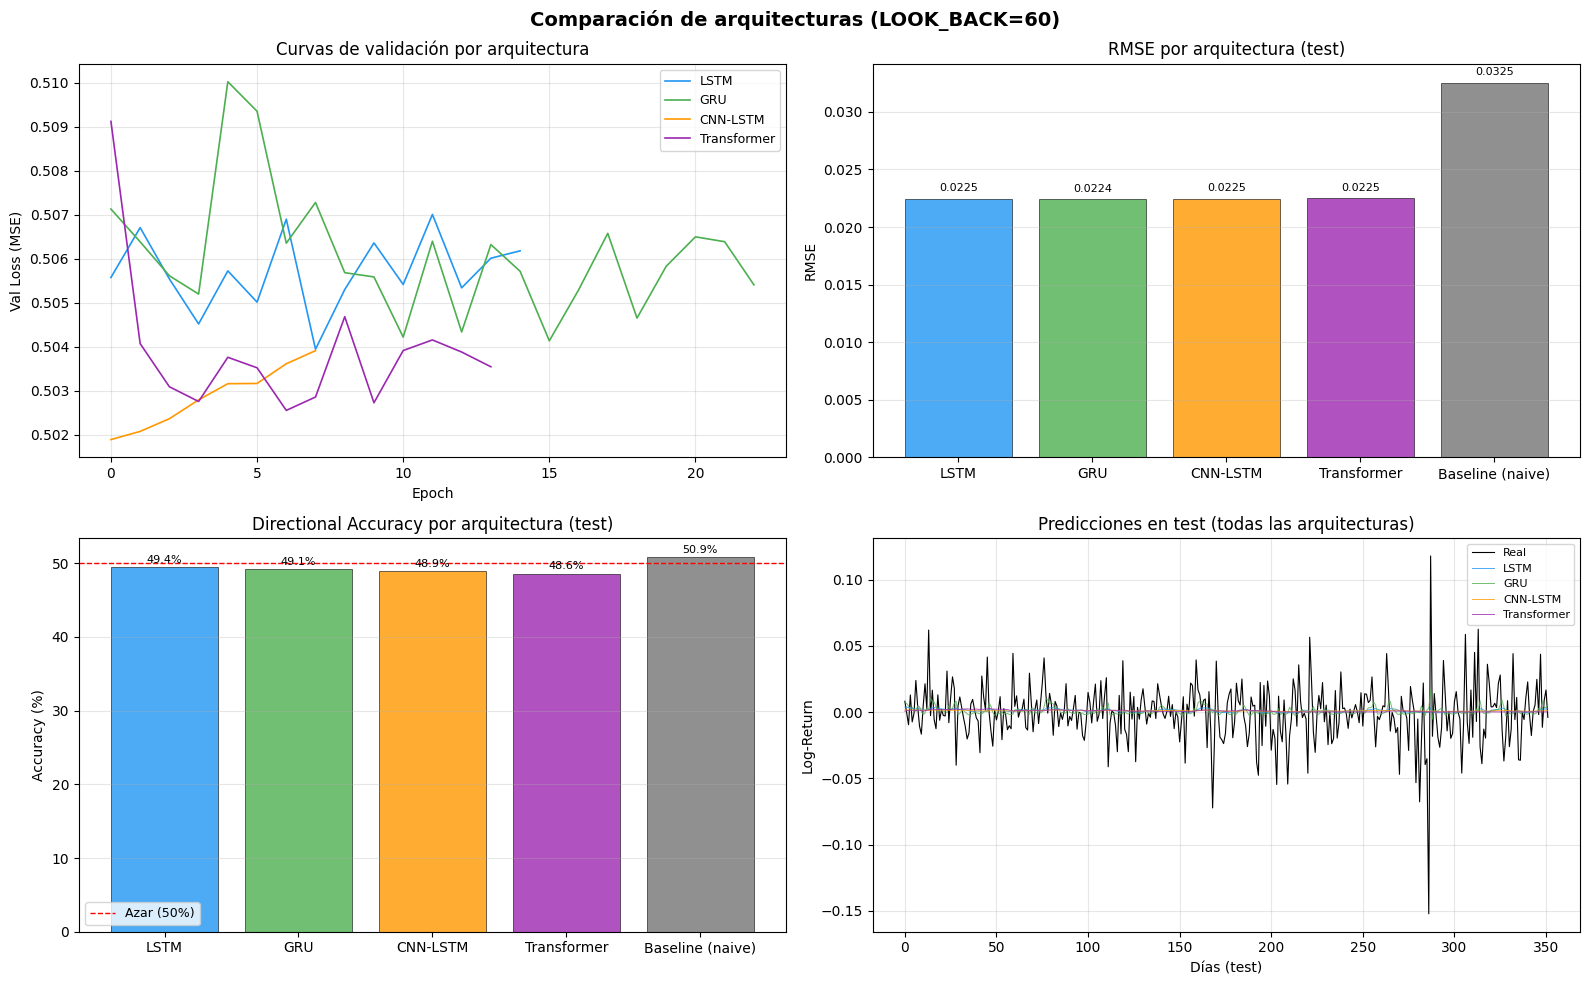

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Panel 1: Curvas de aprendizaje ---
ax1 = axes[0, 0]
colors = {'LSTM': '#2196F3', 'GRU': '#4CAF50', 'CNN-LSTM': '#FF9800', 'Transformer': '#9C27B0'}
for arch_name, hist in histories.items():
    ax1.plot(hist.history['val_loss'], label=arch_name, color=colors[arch_name], linewidth=1.2)
ax1.set_title('Curvas de validación por arquitectura')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Val Loss (MSE)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Barras RMSE ---
ax2 = axes[0, 1]
arch_names = [r['name'] for r in all_results]
rmse_vals = [r['rmse'] for r in all_results]
bar_colors = [colors.get(n, '#757575') for n in arch_names]
bars = ax2.bar(arch_names, rmse_vals, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_title('RMSE por arquitectura (test)')
ax2.set_ylabel('RMSE')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmse_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# --- Panel 3: Barras Directional Accuracy ---
ax3 = axes[1, 0]
da_vals = [r['dir_acc'] for r in all_results]
bars3 = ax3.bar(arch_names, da_vals, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax3.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Azar (50%)')
ax3.set_title('Directional Accuracy por arquitectura (test)')
ax3.set_ylabel('Accuracy (%)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, da_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# --- Panel 4: Predicciones superpuestas ---
ax4 = axes[1, 1]
ax4.plot(results[0]['y_real'], color='black', label='Real', linewidth=0.8)
for r in results:
    ax4.plot(r['y_pred'], color=colors.get(r['name'], 'gray'),
             label=r['name'], linewidth=0.7, alpha=0.8)
ax4.set_title('Predicciones en test (todas las arquitecturas)')
ax4.set_xlabel('Días (test)')
ax4.set_ylabel('Log-Return')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Comparación de arquitecturas (LOOK_BACK={LOOK_BACK})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 8 — Análisis de direccionalidad por arquitectura

In [11]:
from scipy import stats

print("📊 Análisis de direccionalidad por arquitectura")
print("=" * 65)
print(f"{'Arquitectura':<15} {'Aciertos':>10} {'Dir.Acc':>10} {'p-valor':>10} {'Significativo':>14}")
print("-" * 65)

y_real_flat = results[0]['y_real'].flatten()
n_test = len(y_real_flat)

for r in results:
    y_pred_flat = r['y_pred'].flatten()
    correct = np.sum(np.sign(y_real_flat) == np.sign(y_pred_flat))
    da = correct / n_test * 100
    binom_p = 1 - stats.binom.cdf(int(correct) - 1, n_test, 0.5)
    sig = "✅ Sí" if binom_p < 0.05 else "❌ No"
    print(f"{r['name']:<15} {correct:>7}/{n_test:<3} {da:>9.1f}% {binom_p:>10.4f} {sig:>14}")

# Baseline
base_flat = results[0]['y_base'].flatten()
correct_base = np.sum(np.sign(y_real_flat) == np.sign(base_flat))
da_base = correct_base / n_test * 100
binom_p_base = 1 - stats.binom.cdf(int(correct_base) - 1, n_test, 0.5)
sig_base = "✅ Sí" if binom_p_base < 0.05 else "❌ No"
print(f"{'Baseline':<15} {correct_base:>7}/{n_test:<3} {da_base:>9.1f}% {binom_p_base:>10.4f} {sig_base:>14}")

📊 Análisis de direccionalidad por arquitectura
Arquitectura      Aciertos    Dir.Acc    p-valor  Significativo
-----------------------------------------------------------------
LSTM                174/352      49.4%     0.6051           ❌ No
GRU                 173/352      49.1%     0.6454           ❌ No
CNN-LSTM            172/352      48.9%     0.6842           ❌ No
Transformer         171/352      48.6%     0.7211           ❌ No
Baseline            179/352      50.9%     0.3949           ❌ No


#### Interpretación del análisis direccional

Los resultados del test binomial son contundentes: **ninguna arquitectura supera el azar**
en la predicción de dirección. Los p-valores van de 0.60 a 0.72, todos muy lejos del
umbral de significancia (0.05).

Hay un patrón interesante: a mayor complejidad arquitectónica, *peor* directional accuracy:

| Arquitectura | Dir. Acc | Parámetros |
|---|---|---|
| Baseline (naive) | 50.9% | 0 |
| LSTM | 49.4% | 13,217 |
| GRU | 49.1% | 10,241 |
| CNN-LSTM | 48.9% | 8,497 |
| Transformer | 48.6% | 9,185 |

Este patrón no es causal (las diferencias no son significativas), pero sí es revelador:
ningún modelo logra extraer señal direccional, y todos convergen a la estrategia de
"predecir valores cercanos a cero" que minimiza el MSE pero no aporta información útil
sobre si el precio subirá o bajará.


---
### 9 — Scatter plots: Real vs Predicho por arquitectura

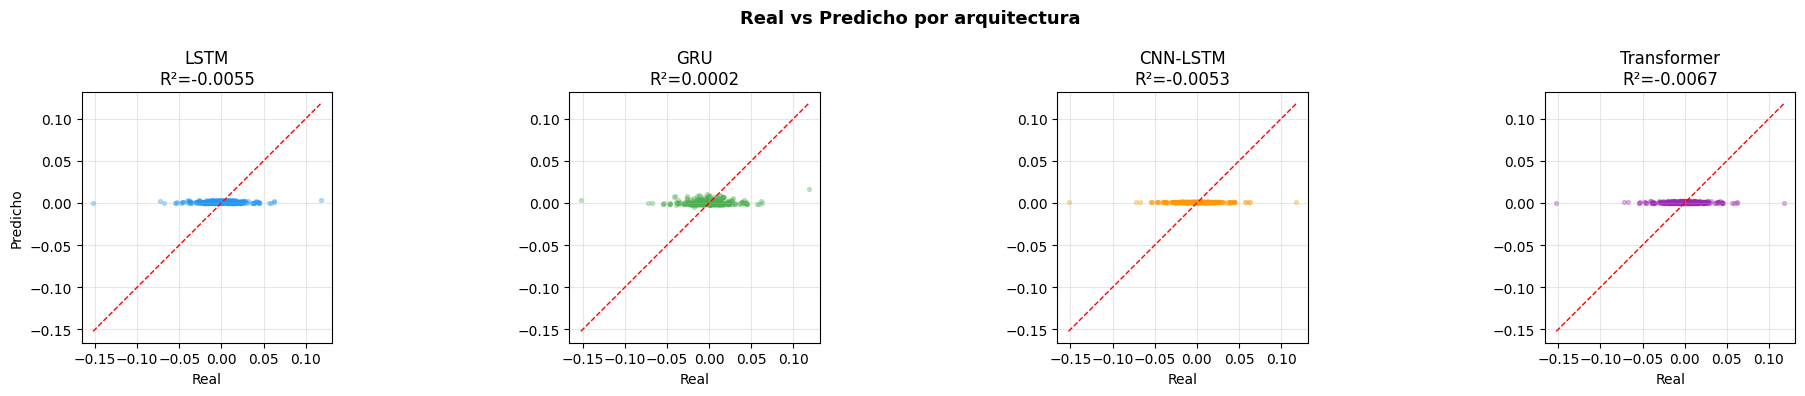

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, r in enumerate(results):
    ax = axes[idx]
    ax.scatter(r['y_real'], r['y_pred'], alpha=0.3, s=8,
               color=colors.get(r['name'], 'gray'))
    lims = [min(r['y_real'].min(), r['y_pred'].min()),
            max(r['y_real'].max(), r['y_pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(f"{r['name']}\nR²={r['r2']:.4f}")
    ax.set_xlabel('Real')
    if idx == 0:
        ax.set_ylabel('Predicho')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Real vs Predicho por arquitectura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Lectura de los scatter plots

Los cuatro scatter plots muestran el mismo patrón: una **nube vertical comprimida** alrededor
del eje Y ≈ 0. Esto significa que todos los modelos predicen valores muy cercanos a cero
(la media de los retornos), sin importar cuál sea el retorno real.

En un modelo con buena capacidad predictiva, los puntos se alinearían a lo largo de la
diagonal roja (y_pred ≈ y_real). En cambio, aquí vemos que los modelos son incapaces
de "comprometerse" con predicciones extremas — nunca predicen retornos de ±5% o más,
aunque estos sí ocurren en la realidad.

Esta es la manifestación visual de la estrategia conservadora que todos los modelos
aprenden: minimizar el MSE prediciendo siempre cerca de la media.


---
### 10 — Test estadístico: ¿alguna arquitectura supera a otra?

Usamos el test de Diebold-Mariano **entre pares de modelos** (no solo vs baseline)
para verificar si las diferencias entre arquitecturas son estadísticamente significativas.

In [13]:
print("📊 Diebold-Mariano entre pares de arquitecturas")
print("   (p < 0.05 → diferencia significativa)")
print("=" * 55)

y_real = results[0]['y_real']
arch_names_nn = [r['name'] for r in results]
n_archs = len(results)

# Matriz de p-valores
dm_matrix = np.ones((n_archs, n_archs))

for i in range(n_archs):
    for j in range(i+1, n_archs):
        e_i = (y_real - results[i]['y_pred']).flatten()
        e_j = (y_real - results[j]['y_pred']).flatten()
        dm_stat, dm_pval = diebold_mariano_test(e_i, e_j)
        dm_matrix[i, j] = dm_pval
        dm_matrix[j, i] = dm_pval
        sig = "*" if dm_pval < 0.05 else " "
        winner = results[i]['name'] if dm_stat > 0 else results[j]['name']
        print(f"  {results[i]['name']:<12} vs {results[j]['name']:<12} | "
              f"p={dm_pval:.4f} {sig} | Menor RMSE: {winner}")

print("\n  * = diferencia significativa al 5%")

📊 Diebold-Mariano entre pares de arquitecturas
   (p < 0.05 → diferencia significativa)
  LSTM         vs GRU          | p=0.7644   | Menor RMSE: LSTM
  LSTM         vs CNN-LSTM     | p=0.9642   | Menor RMSE: LSTM
  LSTM         vs Transformer  | p=0.8293   | Menor RMSE: Transformer
  GRU          vs CNN-LSTM     | p=0.8060   | Menor RMSE: CNN-LSTM
  GRU          vs Transformer  | p=0.7635   | Menor RMSE: Transformer
  CNN-LSTM     vs Transformer  | p=0.5923   | Menor RMSE: Transformer

  * = diferencia significativa al 5%


#### Interpretación del test entre pares

El test de Diebold-Mariano entre pares de arquitecturas arroja p-valores entre
0.59 y 0.96 — **ninguno es significativo**. Esto confirma que las cuatro arquitecturas
producen predicciones **estadísticamente indistinguibles** entre sí.

El caso más extremo es LSTM vs CNN-LSTM con p=0.96, lo que significa que la adición
de capas convolucionales no aporta absolutamente nada sobre la LSTM pura.

En resumen: no importa si usas LSTM, GRU, CNN-LSTM o Transformer — todas las
arquitecturas aprenden exactamente la misma función para este problema.


---
### 11 — Conclusiones de la comparación de arquitecturas

#### Resultado principal

La comparación de cuatro arquitecturas de redes neuronales (LSTM, GRU, CNN-LSTM, Transformer)
bajo condiciones controladas produce un resultado claro y coherente:

| Pregunta | Respuesta | Evidencia |
|---|---|---|
| ¿Alguna arquitectura supera al baseline en RMSE? | **Sí, todas** | DM test p < 0.005 en los 4 casos |
| ¿Alguna supera a las demás en RMSE? | **No** | DM entre pares: p > 0.59 en todos los casos |
| ¿Alguna predice la dirección? | **No, ninguna** | Dir.Acc < 50% en las 4; test binomial p > 0.60 |
| ¿La complejidad ayuda? | **No** | La GRU (10k params) ≈ Transformer (9k) ≈ LSTM (13k) |

#### ¿Por qué todas las arquitecturas producen el mismo resultado?

La explicación está en la **naturaleza de los datos**, no en las herramientas.
Los retornos logarítmicos del BTC se comportan como un proceso muy cercano a un
*random walk* (caminata aleatoria), donde el retorno de mañana es esencialmente
impredecible a partir del historial de precios.

Todas las redes neuronales convergen a la misma estrategia óptima bajo MSE:
**predecir retornos cercanos a cero** (la media histórica). Esta predicción es
"segura" porque minimiza el error cuadrático promedio, pero no contiene información
útil sobre la dirección del siguiente movimiento.

#### Implicación para la Hipótesis de Mercado Eficiente (EMH)

Estos resultados son consistentes con la EMH en su **forma débil**: la información
contenida en los precios históricos ya está reflejada en el precio actual de BTC,
y no es posible obtener ventaja predictiva direccional usando únicamente datos
de precios pasados, independientemente de la sofisticación del modelo empleado.

#### Valor académico del experimento

Este notebook demuestra que:

1. **El método científico funciona:** se formuló una hipótesis ("cambiar la arquitectura
   puede mejorar la predicción"), se diseñó un experimento controlado, y los datos
   refutaron la hipótesis. Un resultado negativo bien fundamentado es tan valioso como
   uno positivo.

2. **La sofisticación no sustituye a la señal:** 4 arquitecturas distintas con ~10,000
   parámetros cada una no pueden superar a una regla de 0 parámetros ("repite el último
   valor") en predicción de dirección. Esto recuerda la máxima de Occam: el modelo más
   simple compatible con los datos es el preferible.

3. **El rigor estadístico es esencial:** sin el test de Diebold-Mariano y el test binomial,
   se podría haber concluido erróneamente que la GRU "ganó" (tiene el menor RMSE).
   Los tests demuestran que la diferencia es ruido estadístico.

#### Posibles líneas futuras

Dado que el cuello de botella es la **información de entrada** (no la arquitectura),
las estrategias más prometedoras serían:

| Estrategia | Idea | Justificación |
|---|---|---|
| **Features exógenas** | Volumen, RSI, MACD, Bollinger Bands | Agregar señales que los precios solos no contienen |
| **Datos alternativos** | Sentimiento de redes sociales, datos on-chain | Información fuera del historial de precios |
| **Clasificación binaria** | Predecir UP/DOWN como clase | Función de pérdida alineada con el objetivo real |
| **Horizonte multi-paso** | Retorno acumulado a 5–10 días | Reducir el ruido de alta frecuencia |
| **Ensemble** | Combinar múltiples modelos | Diversificación de errores |
